# Homework 3
This file contains code to answer a problem on Homework 3 in MATH 6610 taught by Akil Narayan at The University of Utah during the Fall 2026 semester.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [7]:
def approximate_numerical_range(A, num_angles=100):
    angles = np.linspace(0,2*np.pi,100, endpoint=False)
    boundary_points = []

    for theta in angles:
        H_theta = 0.5 * (np.exp(-1j*theta)*A + np.exp(1j*theta) * A.conj().T)
        print(H_theta)
        eigvals, eigvecs = np.linalg.eigh(H_theta)
        x_max = eigvecs[:,-1]
        z = np.vdot(x_max, A @ x_max)
        boundary_points.append(z)
    return boundary_points

A = np.array([[1, 3, 0],
              [0, 2, 1],
              [0, 0, -1]], dtype=complex)

[[ 1. +0.j  1.5+0.j  0. +0.j]
 [ 1.5+0.j  2. +0.j  0.5+0.j]
 [ 0. +0.j  0.5+0.j -1. +0.j]]
[[ 0.99802673+0.j          1.49704009-0.09418578j  0.        +0.j        ]
 [ 1.49704009+0.09418578j  1.99605346+0.j          0.49901336-0.03139526j]
 [ 0.        +0.j          0.49901336+0.03139526j -0.99802673+0.j        ]]
[[ 0.9921147 +0.j          1.48817205-0.18799985j  0.        +0.j        ]
 [ 1.48817205+0.18799985j  1.9842294 +0.j          0.49605735-0.06266662j]
 [ 0.        +0.j          0.49605735+0.06266662j -0.9921147 +0.j        ]]
[[ 0.98228725+0.j          1.47343088-0.28107197j  0.        +0.j        ]
 [ 1.47343088+0.28107197j  1.9645745 +0.j          0.49114363-0.09369066j]
 [ 0.        +0.j          0.49114363+0.09369066j -0.98228725+0.j        ]]
[[ 0.96858316+0.j          1.45287474-0.37303483j  0.        +0.j        ]
 [ 1.45287474+0.37303483j  1.93716632+0.j          0.48429158-0.12434494j]
 [ 0.        +0.j          0.48429158+0.12434494j -0.96858316+0.j        ]]
[[ 0.

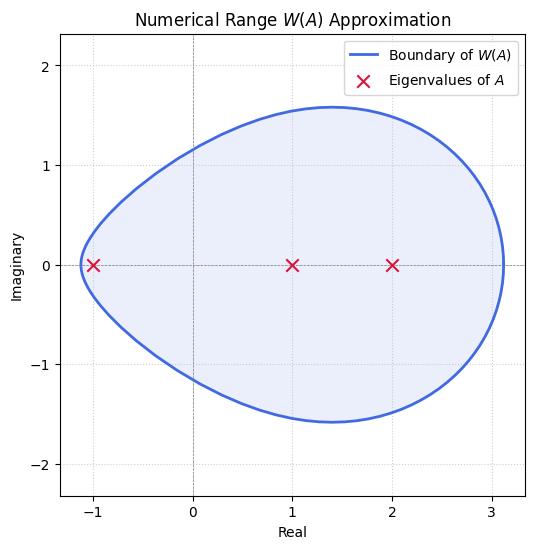

In [8]:
if __name__ == "__main__":
    
    boundary = approximate_numerical_range(A, num_angles=200)
    
    matrix_eigvals = np.linalg.eigvals(A)
    
    plt.figure(figsize=(6, 6))
    
    closed_boundary = np.append(boundary, boundary[0])
    plt.plot(closed_boundary.real, closed_boundary.imag, label="Boundary of $W(A)$", color="royalblue", lw=2)
    plt.fill(closed_boundary.real, closed_boundary.imag, alpha=0.1, color="royalblue")
    
    plt.scatter(matrix_eigvals.real, matrix_eigvals.imag, color="crimson", marker="x", s=80, zorder=3, label="Eigenvalues of $A$")
    
    plt.axhline(0, color='gray', lw=0.5, ls='--')
    plt.axvline(0, color='gray', lw=0.5, ls='--')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.title("Numerical Range $W(A)$ Approximation")
    plt.xlabel("Real")
    plt.ylabel("Imaginary")
    plt.legend()
    plt.axis("equal")
    plt.show()